<a href="https://colab.research.google.com/github/asaputro281-boo/All-Project/blob/main/P04_253307019_Angga_Dwi_Saputro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KEGIATAN 1 — Membangun Graf dengan Dictionary**

In [ ]:
# Kita pakai Dictionary buat bikin "peta"
# Kuncinya itu nama kota, Nah isinya (list) adalah kota-kota yang nempel/terhubung langsung
peta = {
    "Madiun": ["Ngawi", "Ponorogo", "Nganjuk"],  # Madiun jalurnya sambung ke Ngawi, Ponorogo, dan Nganjuk
    "Ngawi": ["Madiun"],                          # Dari Ngawi cuma bisa balik lagi ke Madiun
    "Ponorogo": ["Madiun"],                       # Dari Ponorogo juga cuma bisa balik ke Madiun
    "Nganjuk": ["Madiun", "Kediri", "Jombang"],   # Nganjuk punya 3 jalur cabang
    "Kediri": ["Nganjuk", "Jombang", "Malang"],   # Kediri bisa ke Nganjuk, Jombang, sama Malang
    "Jombang": ["Nganjuk", "Kediri", "Mojokerto"],# Jombang nempel ke Nganjuk, Kediri, dan Mojokerto
    "Mojokerto": ["Jombang", "Surabaya", "Malang"],# Mojokerto cabang ke Jombang, Surabaya, dan Malang
    "Malang": ["Kediri", "Mojokerto", "Surabaya"],# Malang cabang ke Kediri, Mojokerto, dan Surabaya
    "Surabaya": ["Mojokerto", "Malang"]           # Surabaya nempel ke Mojokerto sama Malang
}

# Coba kita tes panggil tetangganya Madiun, harusnya muncul Ngawi, Ponorogo, Nganjuk
print("Tetangga Madiun:", peta["Madiun"])

Tetangga Madiun: ['Ngawi', 'Ponorogo', 'Nganjuk']


# **`PENGEMBANGAN KEGIATAN 1 - Membuat peta pulau dengan dictionary`**

In [ ]:
# Representasi graf peta kepulauan menggunakan Dictionary (Adjacency List)
# Key   = nama pulau (node/vertex)
# Value = list pulau tetangga yang terhubung langsung / 2 arah (edge)
peta_pulau = {
    "Pulau Mula": ["Pulau Tengkorak", "Pulau Sirip", "Pulau Jangkar"],
    "Pulau Tengkorak": ["Pulau Mula"],
    "Pulau Sirip": ["Pulau Mula"],
    "Pulau Jangkar": ["Pulau Mula", "Pulau Karang", "Pulau Meriam"],
    "Pulau Karang": ["Pulau Jangkar", "Pulau Meriam", "Pulau Sirene"],
    # Tambahkan "Pulau Sirene" di sini agar konsisten dua arah dengan Pulau Sirene
    "Pulau Meriam": ["Pulau Jangkar", "Pulau Karang", "Pulau Sirene", "Pulau Harta"],
    "Pulau Sirene": ["Pulau Karang", "Pulau Meriam", "Pulau Harta"],
    "Pulau Harta": ["Pulau Meriam", "Pulau Sirene"]
}

# 1. Mengakses daftar pulau tetangga dari lokasi awal (Pulau Mula)
print("Pulau terdekat dari Pulau Mula:", peta_pulau["Pulau Mula"])

# 2. Menampilkan ringkasan seluruh keterhubungan pulau pada peta
print("\n=== PETA NAVIGASI BAJAK LAUT ===")
for pulau, tetangga in peta_pulau.items():
    print(f"{pulau} -> terhubung ke: {', '.join(tetangga)}")

Pulau terdekat dari Pulau Mula: ['Pulau Tengkorak', 'Pulau Sirip', 'Pulau Jangkar']

=== PETA NAVIGASI BAJAK LAUT ===
Pulau Mula -> terhubung ke: Pulau Tengkorak, Pulau Sirip, Pulau Jangkar
Pulau Tengkorak -> terhubung ke: Pulau Mula
Pulau Sirip -> terhubung ke: Pulau Mula
Pulau Jangkar -> terhubung ke: Pulau Mula, Pulau Karang, Pulau Meriam
Pulau Karang -> terhubung ke: Pulau Jangkar, Pulau Meriam, Pulau Sirene
Pulau Meriam -> terhubung ke: Pulau Jangkar, Pulau Karang, Pulau Sirene, Pulau Harta
Pulau Sirene -> terhubung ke: Pulau Karang, Pulau Meriam, Pulau Harta
Pulau Harta -> terhubung ke: Pulau Meriam, Pulau Sirene


### **Penjelasan Pengembangan Kegiatan 1**
Kodingan ini menyimpan peta kepulauan menggunakan dictionary, di mana nama pulau berfungsi sebagai key dan daftar pulau tetangganya sebagai value. Semua jalur dibuat simetris atau dua arah (seperti Pulau Meriam dan Pulau Sirene) agar algoritma pencarian rute nantinya tidak terjebak. Selanjutnya, perintah peta_pulau["Pulau Mula"] dipakai untuk mengambil tetangga terdekat secara instan, lalu perulangan for merapikan tampilan seluruh peta navigasinya.

# **KEGIATAN 2 — BFS: Rute dengan Langkah Tersedikit**

In [ ]:
def bfs(graf, awal, tujuan):
    # Bikin antrian buat nampung rute, diawali dari kota tempat kita mulai (Madiun)
    antrian = [[awal]]

    # Selama masih ada rute di dalam antrian, lanjut terus pencariannya
    while antrian:
        # Ambil rute paling depan di antrian (Konsep FIFO: Siapa cepat dia dapat / mirip antrean kasir)
        jalur = antrian.pop(0)

        # Cek kota paling ujung/terakhir dari rute yang lagi dipegang
        kota = jalur[-1]

        # Kalau kota ujungnya udah sampe Surabaya (tujuan), mantap! Langsung balikin rutenya
        if kota == tujuan:
            return jalur

        # Kalau belum sampe, cek semua kota tetangga dari kota terkini
        for tetangga in graf[kota]:
            # Biar gak muter-muter kayak komedi putar, cek dulu biar gak lewati kota yang sama
            if tetangga not in jalur:
                # Gabungin rute lama sama kota tetangga baru, terus lempar ke antrian belakang
                antrian.append(jalur + [tetangga])

    # Kalau antrian habis tapi gak ketemu jalurnya, balikin Kosong (None)
    return None

# Panggil fungsi BFS buat nyari rute dari Madiun ke Surabaya
rute_bfs = bfs(peta, "Madiun", "Surabaya")

# Cetak hasilnya pake tanda panah biar rapi
print("Rute BFS:", " -> ".join(rute_bfs))

Rute BFS: Madiun -> Nganjuk -> Kediri -> Malang -> Surabaya


# **`PENGEMBANGAN KEGIATAN 2 - BFS untuk mencari rute dengan jumlah pulau yang dilewati paling sedikit`**

In [ ]:
# Fungsi BFS (Breadth-First Search) untuk mencari rute persinggahan pulau tersedikit
def bfs_bajak_laut(graf, awal, tujuan):
    # Inisialisasi antrian (queue) yang berisi rute awal [[Pulau Mula]]
    antrian = [[awal]]

    # Perulangan selama masih ada rute dalam antrian
    while antrian:
        # Mengambil rute paling depan (FIFO: First-In First-Out)
        jalur = antrian.pop(0)

        # Mengambil pulau terakhir dari rute yang sedang diperiksa
        pulau_sekarang = jalur[-1]

        # Cek apakah pulau saat ini adalah tujuan (Pulau Harta)
        if pulau_sekarang == tujuan:
            return jalur  # Jika sampai, kembalikan rute pelayaran lengkap

        # Menelusuri semua pulau tetangga dari pulau saat ini
        for pulau_tetangga in graf[pulau_sekarang]:
            # Mencegah kapal berputar-putar di pulau yang sudah pernah dikunjungi
            if pulau_tetangga not in jalur:
                # Tambahkan rute baru ke belakang antrian
                antrian.append(jalur + [pulau_tetangga])

    return None  # Kembalikan None jika tidak ada rute yang terhubung

# Memanggil fungsi BFS dari Pulau Mula ke Pulau Harta
rute_bfs = bfs_bajak_laut(peta_pulau, "Pulau Mula", "Pulau Harta")

# Menampilkan hasil rute pelayaran
print("Rute BFS (Jumlah Pulau Tersedikit):")
print(" -> ".join(rute_bfs))

Rute BFS (Jumlah Pulau Tersedikit):
Pulau Mula -> Pulau Jangkar -> Pulau Meriam -> Pulau Harta


###**SIMULASI GIF**

GIF Kegiatan 2 Berhasil Dibuat: pirate_bfs_min_islands.gif

--- Menampilkan GIF Lokal ---


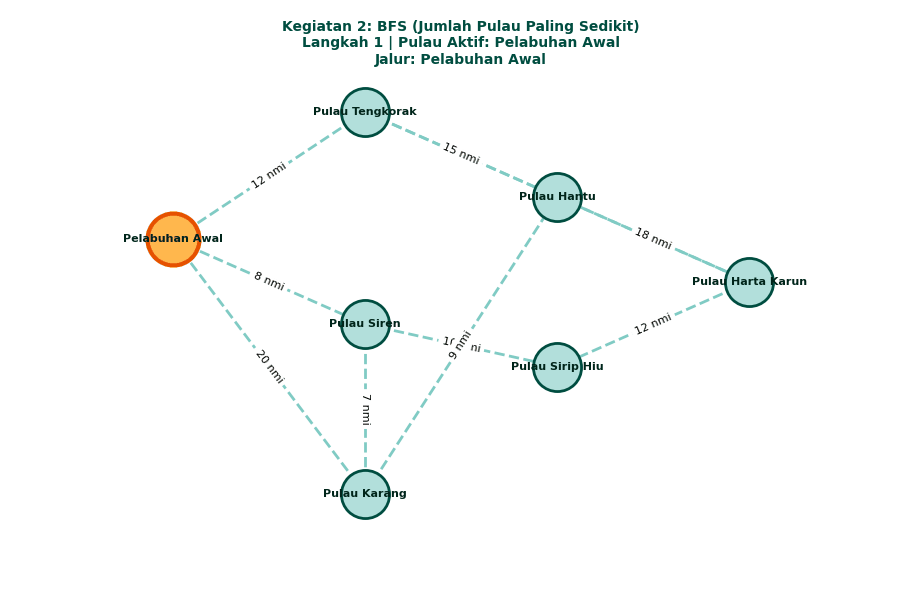

In [ ]:
from collections import deque
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 1. INISIALISASI GRAF PETA LAUT & POSISI
# ==========================================
# Menyimpan daftar pulau dan jalur laut beserta bobot jaraknya (nautical miles)
edges_with_weight = [
    ("Pelabuhan Awal", "Pulau Tengkorak", 12),
    ("Pelabuhan Awal", "Pulau Siren", 8),
    ("Pelabuhan Awal", "Pulau Karang", 20),
    ("Pulau Tengkorak", "Pulau Hantu", 15),
    ("Pulau Tengkorak", "Pulau Harta Karun", 35),  # Jalur langsung (2 lompatan)
    ("Pulau Siren", "Pulau Sirip Hiu", 10),
    ("Pulau Siren", "Pulau Karang", 7),
    ("Pulau Sirip Hiu", "Pulau Harta Karun", 12),
    ("Pulau Karang", "Pulau Hantu", 9),
    ("Pulau Hantu", "Pulau Harta Karun", 18),
]

# Membuat objek Graf Tak Berarah (Undirected Graph) menggunakan NetworkX
G = nx.Graph()
for u, v, w in edges_with_weight:
  G.add_edge(u, v, weight=w)  # Menambahkan sisi/jalur antar pulau

# Menentukan tata letak koordinat (X, Y) untuk visualisasi peta di layar
pos = {
    "Pelabuhan Awal": (0, 2),
    "Pulau Tengkorak": (2, 3.5),
    "Pulau Siren": (2, 1),
    "Pulau Karang": (2, -1),
    "Pulau Hantu": (4, 2.5),
    "Pulau Sirip Hiu": (4, 0.5),
    "Pulau Harta Karun": (6, 1.5),
}


# ==========================================
# 2. LOGIKA ALGORITMA BFS (QUEUE / FIFO)
# ==========================================
def run_bfs(start, goal):
  frames = []  # Menyimpan snapshot setiap langkah untuk animasi
  queue = deque([[start]])  # Antrean (Queue) FIFO berisi jalur pelayaran
  visited = set([start])  # Set untuk mencatat pulau yang sudah dikunjungi

  while queue:
    path = queue.popleft()  # Ambil jalur terdepan dari antrean (FIFO)
    node = path[-1]  # Pulau yang sedang diekspansi saat ini

    # Mencatat data visual: edge jalur aktif & pulau dalam antrean (frontier)
    tree_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    frontier = [p[-1] for p in queue]
    frames.append(
        (node, list(visited), frontier, tree_edges, path)
    )  # Simpan snapshot

    # Jika sudah sampai di pulau tujuan, hentikan pencarian
    if node == goal:
      break

    # Cek semua pulau tetangga yang terhubung
    for neighbor in sorted(G.neighbors(node)):
      if neighbor not in visited:
        visited.add(neighbor)  # Tandai sudah dikunjungi
        queue.append(path + [neighbor])  # Masukkan jalur baru ke antrean

  return frames


# ==========================================
# 3. VISUALISASI & PEMBUATAN ANIMASI GIF
# ==========================================
# Jalankan pencarian BFS dari Pelabuhan Awal ke Pulau Harta Karun
frames = run_bfs("Pelabuhan Awal", "Pulau Harta Karun")
fig, ax = plt.subplots(figsize=(9, 6))


# Fungsi yang dipanggil secara berulang untuk menggambar tiap frame animasi
def animate(frame):
  ax.clear()  # Bersihkan kanvas sebelum menggambar frame baru

  # Ambil data snapshot langkah saat ini
  current_node, visited, frontier, tree_edges, current_path = frames[
      min(frame, len(frames) - 1)
  ]

  # Set warna latar belakang menyerupai lautan
  ax.set_facecolor("#E0F7FA")

  # Gambar dasar pulau (node) dan jalur laut (edge)
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      node_color="#B2DFDB",
      node_size=1200,
      edgecolors="#004D40",
      linewidths=2,
  )
  nx.draw_networkx_edges(
      G, pos, ax=ax, edge_color="#80CBC4", width=2, style="dashed"
  )

  # Tampilkan label jarak laut (nautical miles) pada garis
  edge_labels = nx.get_edge_attributes(G, "weight")
  formatted_labels = {k: f"{v} nmi" for k, v in edge_labels.items()}
  nx.draw_networkx_edge_labels(
      G, pos, edge_labels=formatted_labels, ax=ax, font_size=8
  )

  # Tampilkan nama-nama pulau
  nx.draw_networkx_labels(
      G, pos, ax=ax, font_size=8, font_weight="bold", font_color="#00251A"
  )

  # Warnai pulau yang sudah pernah dikunjungi (Closed List)
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=visited,
      node_color="#80DEEA",
      node_size=1200,
      edgecolors="#00838F",
  )

  # Warnai pulau kandidat yang ada dalam antrean (Frontier/Open List)
  frontier_nodes = [n for n in frontier if n not in visited]
  if frontier_nodes:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=frontier_nodes,
        node_color="#FFF59D",
        node_size=1200,
        edgecolors="#FBC02D",
    )

  # Sorot pulau aktif yang sedang diekspansi kapal saat ini (Oranye)
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=[current_node],
      node_color="#FFB74D",
      node_size=1400,
      edgecolors="#E65100",
      linewidths=3,
  )

  # Jika sampai di Pulau Harta Karun, beri warna khusus (Kuning Emas)
  if current_node == "Pulau Harta Karun":
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=["Pulau Harta Karun"],
        node_color="#FFD54F",
        node_size=1600,
        edgecolors="#FF6F00",
        linewidths=3,
    )

  # Tebalkan garis jalur yang dilalui kapal
  if tree_edges:
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=tree_edges, edge_color="#D81B60", width=3.5
    )

  # Atur judul dan keterangan langkah animasi
  step_num = min(frame + 1, len(frames))
  path_str = " -> ".join(current_path)
  ax.set_title(
      f"Kegiatan 2: BFS (Jumlah Pulau Paling Sedikit)\nLangkah {step_num} |"
      f" Pulau Aktif: {current_node}\nJalur: {path_str}",
      fontsize=10,
      fontweight="bold",
      color="#004D40",
  )
  ax.axis("off")  # Sembunyikan sumbu X dan Y


# Proses render dan simpan animasi ke file GIF
gif_filename = "pirate_bfs_min_islands.gif"
ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=1200)
ani.save(gif_filename, writer="pillow", fps=1)
plt.close()
print(f"GIF Kegiatan 2 Berhasil Dibuat: {gif_filename}")


# ==========================================
# 4. TAMBAHAN: MENAMPILKAN GIF
# ==========================================
from IPython.display import Image, display

# Opsi A: Menampilkan GIF Lokal (Berhasil langsung setelah di-run)
# Cara ini akan menampilkan GIF yang baru saja dibuat di folder yang sama.
# Ini sangat berguna jika Anda mengerjakannya di Jupyter Notebook atau Google Colab.
print("\n--- Menampilkan GIF Lokal ---")
display(Image(filename=gif_filename))


# Opsi B: Menampilkan GIF dari GitHub (Membutuhkan langkah manual)
# Cara ini menampilkan GIF yang sudah diunggah ke repository GitHub Anda.
# Ini sangat berguna jika Anda ingin membagikan link hasil running kodingan Anda.

# Langkah Manual Terlebih Dahulu:
# 1. Pastikan kodingan ini sudah selesai dijalankan dan file GIF-nya terbentuk di komputer Anda.
# 2. Gunakan terminal/aplikasi Git Anda untuk melakukan push:
#    a. git add pirate_bfs_min_islands.gif
#    b. git commit -m "Menambahkan GIF hasil BFS"
#    c. git push
# 3. Masuk ke repository GitHub Anda lewat browser.
# 4. Cari file GIF yang baru saja di-push, lalu klik kanan pada file tersebut dan pilih "Copy image link" atau "Copy image address".

# Ganti URL di bawah dengan URL mentah (raw URL) dari GitHub Anda.
# URL mentah biasanya terlihat seperti ini: https://raw.githubusercontent.com/USERNAME/REPO_NAME/BRANCH/path/to/pirate_bfs_min_islands.gif
github_raw_url = "https://github.com/asaputro281-boo/All-Project/blob/95996665c32ac7cf00a85847185220feeea10b93/pirate_astar_shortest_route.gif"

# Buka komentar dua baris di bawah setelah URL diganti
# print("\n--- Menampilkan GIF dari GitHub ---")
# display(Image(url=github_raw_url))

### **Penjelasan Pengembangan Kegiatan 2**
Kode bfs_bajak_laut menggunakan prinsip Breadth-First Search (BFS) berbasis antrean FIFO (pop(0)) untuk menjelajahi pulau level demi level. Hasilnya menjamin rute pelayaran dengan jumlah persinggahan pulau tersedikit dari Pulau Mula ke Pulau Harta tanpa terjebak siklus mutar-mutar

# **KEGIATAN 3 — DFS: Ubah Satu Baris**

In [ ]:
def dfs(graf, awal, tujuan):
    # Bikin tumpukan buat nyimpen rute perjalanan awal
    tumpukan = [[awal]]

    # Selama tumpukan gak kosong, kita jelajah terus
    while tumpukan:
        # Bedanya sama BFS cuma di sini!
        # pop() tanpa angka artinya ambil rute PALING BELAKANG / PALING BARU (Konsep LIFO: Mirip tumpukan piring)
        # Efeknya: Dia bakal "menyelam" masuk ke satu cabang jalan sampe mentok dulu
        jalur = tumpukan.pop()

        # Cek posisi kota paling ujung saat ini
        kota = jalur[-1]

        # Kalau ketemu Surabaya, langsung balikin rutenya!
        if kota == tujuan:
            return jalur

        # Cek kota-kota tetangganya
        for tetangga in graf[kota]:
            # Jangan sampe muter balik ke kota yang udah pernah dilewati
            if tetangga not in jalur:
                # Tumpuk rute baru ini ke paling atas
                tumpukan.append(jalur + [tetangga])

    return None

# Panggil fungsi DFS buat cari jalan dari Madiun ke Surabaya
rute_dfs = dfs(peta, "Madiun", "Surabaya")

# Cetak hasil rute penyelaman ala DFS
print("Rute DFS:", " -> ".join(rute_dfs))

Rute DFS: Madiun -> Nganjuk -> Jombang -> Mojokerto -> Malang -> Surabaya


# **`PENGEMBANGAN KEGIATAN 3 - DFS untuk menjelajahi pulau-pulau yang tersedia`**

In [ ]:
# Fungsi DFS (Depth-First Search) untuk eksplorasi jalur laut secara mendalam
def dfs_bajak_laut(graf, awal, tujuan):
    # Inisialisasi tumpukan (stack) yang berisi rute awal [[Pulau Mula]]
    tumpukan = [[awal]]

    # Perulangan selama masih ada rute dalam tumpukan
    while tumpukan:
        # Mengambil rute paling belakang/teratas (LIFO: Last-In First-Out)
        # Menjelajah satu cabang sampai mentok baru mundur
        jalur = tumpukan.pop()

        # Mengambil pulau terakhir dari rute yang sedang diperiksa
        pulau_sekarang = jalur[-1]

        # Cek apakah pulau saat ini adalah tujuan (Pulau Harta)
        if pulau_sekarang == tujuan:
            return jalur  # Kembalikan rute jika berhasil menemukan tujuan

        # Menelusuri semua pulau tetangga dari pulau saat ini
        for pulau_tetangga in graf[pulau_sekarang]:
            # Mencegah kapal berputar balik
            if pulau_tetangga not in jalur:
                # Masukkan rute baru ke atas tumpukan
                tumpukan.append(jalur + [pulau_tetangga])

    return None  # Kembalikan None jika tidak menemukan rute

# Memanggil fungsi DFS dari Pulau Mula ke Pulau Harta
rute_dfs = dfs_bajak_laut(peta_pulau, "Pulau Mula", "Pulau Harta")

# Menampilkan hasil rute eksplorasi DFS
print("Rute DFS (Eksplorasi Mendalam):")
print(" -> ".join(rute_dfs))

Rute DFS (Eksplorasi Mendalam):
Pulau Mula -> Pulau Jangkar -> Pulau Meriam -> Pulau Harta


### **SIMULASI GIF**

GIF Kegiatan 3 Berhasil Dibuat: pirate_dfs_exploration.gif

--- Menampilkan GIF Lokal ---


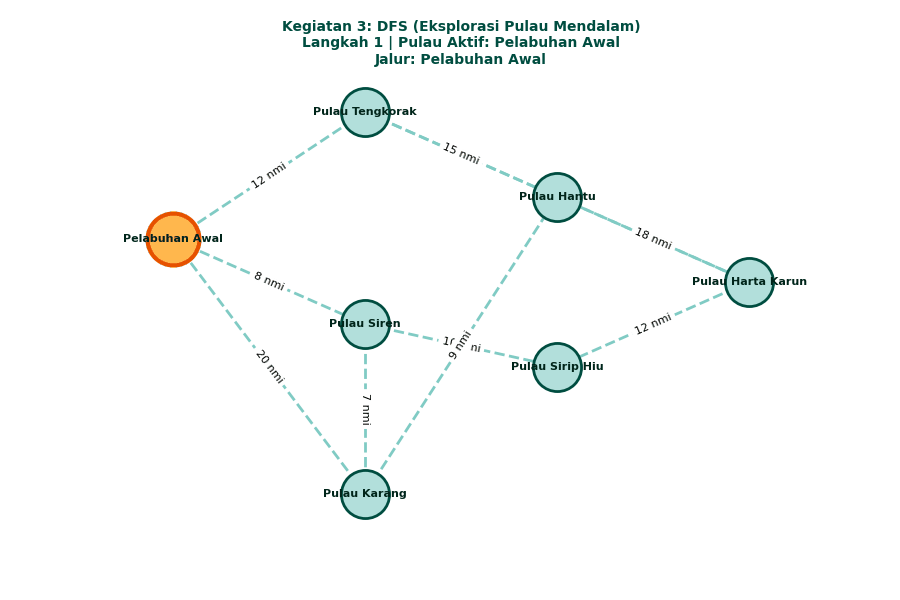

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 1. INISIALISASI GRAF PETA LAUT & POSISI
# ==========================================
edges_with_weight = [
    ("Pelabuhan Awal", "Pulau Tengkorak", 12),
    ("Pelabuhan Awal", "Pulau Siren", 8),
    ("Pelabuhan Awal", "Pulau Karang", 20),
    ("Pulau Tengkorak", "Pulau Hantu", 15),
    ("Pulau Tengkorak", "Pulau Harta Karun", 35),
    ("Pulau Siren", "Pulau Sirip Hiu", 10),
    ("Pulau Siren", "Pulau Karang", 7),
    ("Pulau Sirip Hiu", "Pulau Harta Karun", 12),
    ("Pulau Karang", "Pulau Hantu", 9),
    ("Pulau Hantu", "Pulau Harta Karun", 18),
]

G = nx.Graph()
for u, v, w in edges_with_weight:
  G.add_edge(u, v, weight=w)

pos = {
    "Pelabuhan Awal": (0, 2),
    "Pulau Tengkorak": (2, 3.5),
    "Pulau Siren": (2, 1),
    "Pulau Karang": (2, -1),
    "Pulau Hantu": (4, 2.5),
    "Pulau Sirip Hiu": (4, 0.5),
    "Pulau Harta Karun": (6, 1.5),
}


# ==========================================
# 2. LOGIKA ALGORITMA DFS (STACK / LIFO)
# ==========================================
def run_dfs(start, goal):
  frames = []  # Menyimpan snapshot setiap langkah
  stack = [[start]]  # Tumpukan (Stack) LIFO berisi jalur pelayaran
  visited = set()  # Set untuk mencatat pulau yang sudah dieksplorasi

  while stack:
    path = stack.pop()  # Ambil jalur paling atas/terakhir dari tumpukan (LIFO)
    node = path[-1]  # Pulau yang sedang dijangkau saat ini

    if node not in visited:
      visited.add(node)  # Tandai pulau sebagai terjelajah

      # Catat snapshot data visual untuk frame animasi
      tree_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
      frontier = [p[-1] for p in stack if p[-1] not in visited]
      frames.append((node, list(visited), frontier, tree_edges, path))

      # Hentikan pencarian jika target telah ditemukan
      if node == goal:
        break

      # Masukkan pulau tetangga ke stack secara terbalik (agar urutan abjad diproses dulu)
      for neighbor in sorted(G.neighbors(node), reverse=True):
        if neighbor not in visited:
          stack.append(path + [neighbor])

  return frames


# ==========================================
# 3. VISUALISASI & PEMBUATAN ANIMASI GIF
# ==========================================
frames = run_dfs("Pelabuhan Awal", "Pulau Harta Karun")
fig, ax = plt.subplots(figsize=(9, 6))


def animate(frame):
  ax.clear()  # Bersihkan kanvas

  # Ambil data snapshot langkah saat ini
  current_node, visited, frontier, tree_edges, current_path = frames[
      min(frame, len(frames) - 1)
  ]

  ax.set_facecolor("#E0F7FA")  # Warna latar belakang lautan

  # Gambar pulau dan garis jalur laut
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      node_color="#B2DFDB",
      node_size=1200,
      edgecolors="#004D40",
      linewidths=2,
  )
  nx.draw_networkx_edges(
      G, pos, ax=ax, edge_color="#80CBC4", width=2, style="dashed"
  )

  # Label bobot jarak & nama pulau
  edge_labels = nx.get_edge_attributes(G, "weight")
  formatted_labels = {k: f"{v} nmi" for k, v in edge_labels.items()}
  nx.draw_networkx_edge_labels(
      G, pos, edge_labels=formatted_labels, ax=ax, font_size=8
  )
  nx.draw_networkx_labels(
      G, pos, ax=ax, font_size=8, font_weight="bold", font_color="#00251A"
  )

  # Status pulau: Visited (Biru) & Frontier/Stack (Kuning)
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=visited,
      node_color="#80DEEA",
      node_size=1200,
      edgecolors="#00838F",
  )
  frontier_nodes = [n for n in frontier if n not in visited]
  if frontier_nodes:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=frontier_nodes,
        node_color="#FFF59D",
        node_size=1200,
        edgecolors="#FBC02D",
    )

  # Pulau aktif saat ini (Oranye) & Pulau Tujuan (Kuning Emas)
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=[current_node],
      node_color="#FFB74D",
      node_size=1400,
      edgecolors="#E65100",
      linewidths=3,
  )
  if current_node == "Pulau Harta Karun":
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=["Pulau Harta Karun"],
        node_color="#FFD54F",
        node_size=1600,
        edgecolors="#FF6F00",
        linewidths=3,
    )

  # Gambar garis pelayaran mendalam yang ditempuh
  if tree_edges:
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=tree_edges, edge_color="#D81B60", width=3.5
    )

  # Atur judul dan info teks
  step_num = min(frame + 1, len(frames))
  path_str = " -> ".join(current_path)
  ax.set_title(
      f"Kegiatan 3: DFS (Eksplorasi Pulau Mendalam)\nLangkah {step_num} |"
      f" Pulau Aktif: {current_node}\nJalur: {path_str}",
      fontsize=10,
      fontweight="bold",
      color="#004D40",
  )
  ax.axis("off")


# Simpan ke GIF
gif_filename = "pirate_dfs_exploration.gif"
ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=1200)
ani.save(gif_filename, writer="pillow", fps=1)
plt.close()
print(f"GIF Kegiatan 3 Berhasil Dibuat: {gif_filename}")


# ==========================================
# 4. TAMBAHAN: MENAMPILKAN GIF
# ==========================================
from IPython.display import Image, display

# Opsi A: Menampilkan GIF Lokal (Otomatis muncul di Notebook/Colab)
print("\n--- Menampilkan GIF Lokal ---")
display(Image(filename=gif_filename))

# Opsi B: Menampilkan GIF dari GitHub (Link Raw URL setelah di-push)
# Ganti URL di bawah sesuai repository Anda:
github_raw_url = "https://github.com/asaputro281-boo/All-Project/blob/95996665c32ac7cf00a85847185220feeea10b93/pirate_dfs_exploration.gif"

# Buka komentar dua baris di bawah jika URL GitHub sudah disesuaikan:
# print("\n--- Menampilkan GIF dari GitHub ---")
# display(Image(url=github_raw_url))

### **Penjelasan Pengambangan Kegiatan 3**
Fungsi dfs_bajak_laut menerapkan algoritma Depth-First Search (DFS) menggunakan struktur data tumpukan (stack) dengan mekanisme LIFO (pop()). Algoritma ini memprioritaskan penelusuran satu cabang pulau secara mendalam hingga menemukan Pulau Harta atau mencapai jalan buntu.

# **KEGIATAN 4 — A : Mencari Rute Terpendek dalam Kilometer**

In [ ]:
# Peta berbobot: Dictionary dalam dictionary buat nyimpen jarak antar kota (km)
jarak = {
    "Madiun": {"Ngawi": 32, "Ponorogo": 29, "Nganjuk": 47},
    "Ngawi": {"Madiun": 32},
    "Ponorogo": {"Madiun": 29},
    "Nganjuk": {"Madiun": 47, "Kediri": 28, "Jombang": 40},
    "Kediri": {"Nganjuk": 28, "Jombang": 39, "Malang": 79},
    "Jombang": {"Nganjuk": 40, "Kediri": 39, "Mojokerto": 24},
    "Mojokerto": {"Jombang": 24, "Surabaya": 45, "Malang": 61},
    "Malang": {"Kediri": 79, "Mojokerto": 61, "Surabaya": 94},
    "Surabaya": {"Mojokerto": 45, "Malang": 94}
}

# Heuristik (h): Perkiraan/pembacaan "garis lurus" dari tiap kota ke Surabaya (km)
h = {
    "Madiun": 140, "Ngawi": 155, "Ponorogo": 160, "Nganjuk": 100,
    "Kediri": 95, "Jombang": 60, "Mojokerto": 40, "Malang": 65,
    "Surabaya": 0  # Kota tujuan heuristiknya pasti 0
}

def a_star(jarak, h, awal, tujuan):
    # List 'terbuka' isinya bentuk tuple: (f, g, jalur)
    # f = perkiraan total jarak (g + h), g = jarak riil yang udah ditempuh, jalur = rutenya
    terbuka = [(h[awal], 0, [awal])]

    while terbuka:
        # Urutin dari f yang PING KECIL/Paling hemat. A* pintar karena gak bakal milih rute yang boros!
        terbuka.sort()

        # Ambil rute paling efisien (f terendah) dari list
        f, g, jalur = terbuka.pop(0)

        # Cek posisi kota paling ujung
        kota = jalur[-1]

        # Kalau udah nyampe Surabaya, kirim balik rute sama total kilometer nyatanya (g)
        if kota == tujuan:
            return jalur, g

        # Cek cabang tetangga dan hitung jarak kilometernya pakai .items()
        for tetangga, km in jarak[kota].items():
            if tetangga not in jalur:  # Jangan sampe muter-muter
                g_baru = g + km                            # Jarak riil nambah sesuai km jalan
                f_baru = g_baru + h[tetangga]              # Rumus sakti A*: f = g + h
                terbuka.append((f_baru, g_baru, jalur + [tetangga]))  # Masukin ke list calon rute

    return None, None

# Uji coba nyari rute tercanggih (A*) Madiun ke Surabaya
rute_astar, total_km = a_star(jarak, h, "Madiun", "Surabaya")

# Tampilkan hasil rute terbaik beserta total kilometer aslinya
print("Rute A*:", " -> ".join(rute_astar), f"| Total: {total_km} km")

Rute A*: Madiun -> Nganjuk -> Jombang -> Mojokerto -> Surabaya | Total: 156 km


# **`PENGEMBANGAN KEGIATAN 4 - A* untuk mencari rute laut dengan jarak terpendek`**

In [ ]:
# 1. Graf Berbobot: Jarak laut nyata antar pulau (dalam satuan Mil Laut)
# Menggunakan nested dictionary: Kota -> (Tetangga -> Jarak Mil)
jarak_pulau = {
    "Pulau Mula": {"Pulau Tengkorak": 32, "Pulau Sirip": 29, "Pulau Jangkar": 47},
    "Pulau Tengkorak": {"Pulau Mula": 32},
    "Pulau Sirip": {"Pulau Mula": 29},
    "Pulau Jangkar": {"Pulau Mula": 47, "Pulau Karang": 28, "Pulau Meriam": 40},
    "Pulau Karang": {"Pulau Jangkar": 28, "Pulau Meriam": 39, "Pulau Sirene": 79},
    "Pulau Meriam": {"Pulau Jangkar": 40, "Pulau Karang": 39, "Pulau Harta": 45},
    "Pulau Sirene": {"Pulau Karang": 79, "Pulau Meriam": 61, "Pulau Harta": 94},
    "Pulau Harta": {"Pulau Meriam": 45, "Pulau Sirene": 94}
}

# 2. Heuristik (h): Perkiraan jarak garis lurus dari setiap pulau ke Pulau Harta
# Nilai heuristik untuk Pulau Harta (tujuan) wajib 0
h_pulau = {
    "Pulau Mula": 140,
    "Pulau Tengkorak": 155,
    "Pulau Sirip": 160,
    "Pulau Jangkar": 100,
    "Pulau Karang": 95,
    "Pulau Meriam": 60,
    "Pulau Sirene": 65,
    "Pulau Harta": 0
}

# 3. Fungsi Algoritma A* (A-Star)
def a_star_bajak_laut(jarak, h, awal, tujuan):
    # Format tuple dalam list terbuka: (f, g, jalur)
    # f = g + h (Total perkiraan biaya)
    # g = Jarak nyata yang sudah ditempuh (awal = 0 mil)
    terbuka = [(h[awal], 0, [awal])]

    while terbuka:
        # Mengurutkan list terbuka berdasarkan nilai f terkecil ke paling depan
        terbuka.sort()

        # Ambil calon rute dengan f paling kecil (paling menjanjikan)
        f, g, jalur = terbuka.pop(0)

        # Ambil pulau posisi terkini
        pulau_sekarang = jalur[-1]

        # Jika pulau saat ini adalah tujuan, kembalikan rute dan total jarak g
        if pulau_sekarang == tujuan:
            return jalur, g

        # Mengambil tetangga beserta jarak mil lautnya (.items())
        for pulau_tetangga, mil in jarak[pulau_sekarang].items():
            if pulau_tetangga not in jalur:
                # hitung g_baru = jarak g saat ini + jarak ke pulau tetangga
                g_baru = g + mil

                # hitung f_baru = g_baru + h (heuristik pulau tetangga)
                f_baru = g_baru + h[pulau_tetangga]

                # Masukkan calon rute baru ke daftar terbuka
                terbuka.append((f_baru, g_baru, jalur + [pulau_tetangga]))

    return None, None  # Jika rute tidak ditemukan

# Memanggil fungsi A* dari Pulau Mula ke Pulau Harta
rute_astar, total_jarak = a_star_bajak_laut(jarak_pulau, h_pulau, "Pulau Mula", "Pulau Harta")

# Menampilkan hasil rute optimal beserta total jarak mil lautnya
print("Rute A* (Jarak Pelayaran Optimal):")
print(" -> ".join(rute_astar), f"\nTotal Jarak Laut: {total_jarak} mil laut")

Rute A* (Jarak Pelayaran Optimal):
Pulau Mula -> Pulau Jangkar -> Pulau Meriam -> Pulau Harta 
Total Jarak Laut: 132 mil laut


### **SIMULASI GIF**

GIF Kegiatan 4 Berhasil Dibuat: pirate_astar_shortest_route.gif

--- Menampilkan GIF Lokal ---


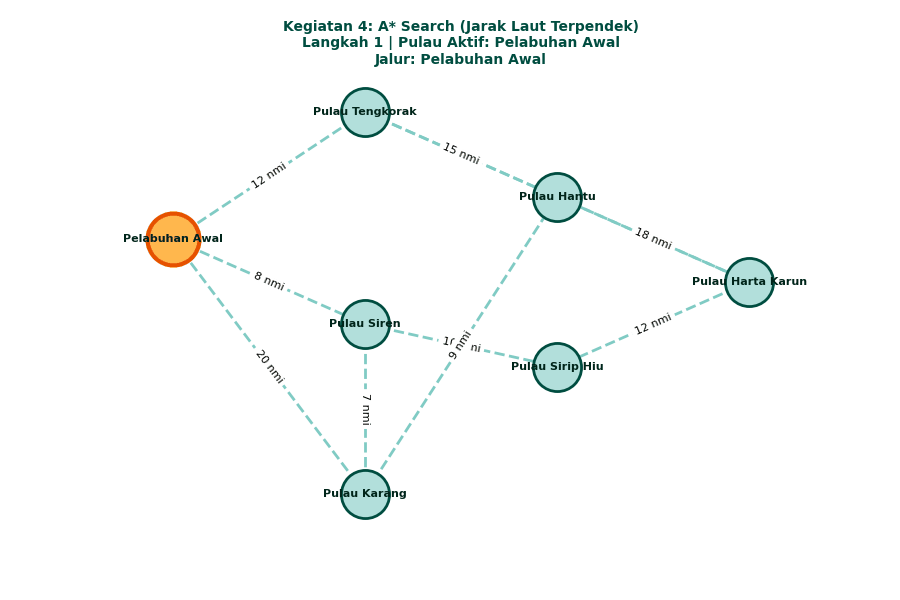

In [ ]:
import heapq
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 1. INISIALISASI GRAF & NILA HEURISTIK h(n)
# ==========================================
edges_with_weight = [
    ("Pelabuhan Awal", "Pulau Tengkorak", 12),
    ("Pelabuhan Awal", "Pulau Siren", 8),
    ("Pelabuhan Awal", "Pulau Karang", 20),
    ("Pulau Tengkorak", "Pulau Hantu", 15),
    ("Pulau Tengkorak", "Pulau Harta Karun", 35),
    ("Pulau Siren", "Pulau Sirip Hiu", 10),
    ("Pulau Siren", "Pulau Karang", 7),
    (
        "Pulau Sirip Hiu",
        "Pulau Harta Karun",
        12,
    ),  # Rute optimal A* (Total = 30 nmi)
    ("Pulau Karang", "Pulau Hantu", 9),
    ("Pulau Hantu", "Pulau Harta Karun", 18),
]

G = nx.Graph()
for u, v, w in edges_with_weight:
  G.add_edge(u, v, weight=w)

pos = {
    "Pelabuhan Awal": (0, 2),
    "Pulau Tengkorak": (2, 3.5),
    "Pulau Siren": (2, 1),
    "Pulau Karang": (2, -1),
    "Pulau Hantu": (4, 2.5),
    "Pulau Sirip Hiu": (4, 0.5),
    "Pulau Harta Karun": (6, 1.5),
}

# Nilai Heuristik h(n): Estimasi jarak garis lurus dari tiap pulau ke Pulau Harta Karun
h = {
    "Pelabuhan Awal": 28,
    "Pulau Tengkorak": 30,
    "Pulau Siren": 20,
    "Pulau Karang": 22,
    "Pulau Hantu": 16,
    "Pulau Sirip Hiu": 10,
    "Pulau Harta Karun": 0,  # Goal
}


# ==========================================
# 2. LOGIKA ALGORITMA A* (PRIORITY QUEUE)
# ==========================================
def run_astar(start, goal):
  frames = []  # Menyimpan snapshot visual
  # Priority Queue menyimpan tuple: (f_score, jalur_pelayaran, g_score)
  # f(n) = g(n) + h(n)
  pq = [(h[start], [start], 0)]
  visited = set()  # Closed List

  while pq:
    # Pop nilai f_score terkecil dari Priority Queue
    f, path, g = heapq.heappop(pq)
    node = path[-1]  # Pulau dengan estimasi biaya paling optimal

    # Abaikan jika pulau sudah pernah dievaluasi
    if node in visited:
      continue
    visited.add(node)

    # Catat snapshot data visual untuk animasi
    tree_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    frontier = [p[-1] for _, p, _ in pq if p[-1] not in visited]
    frames.append((node, list(visited), frontier, tree_edges, path))

    # Jika sudah mencapai target, hentikan algoritma
    if node == goal:
      break

    # Hitung biaya baru untuk pulau tetangga
    for neighbor in G.neighbors(node):
      if neighbor not in visited:
        weight = G[node][neighbor]["weight"]  # Biaya jarak asli g(n)
        new_g = g + weight  # Akumulasi jarak dari titik awal
        new_f = new_g + h[neighbor]  # Nilai f(n) = g(n) + h(n)

        # Masukkan jalur baru ke Priority Queue
        heapq.heappush(pq, (new_f, path + [neighbor], new_g))

  return frames


# ==========================================
# 3. VISUALISASI & PEMBUATAN ANIMASI GIF
# ==========================================
frames = run_astar("Pelabuhan Awal", "Pulau Harta Karun")
fig, ax = plt.subplots(figsize=(9, 6))


def animate(frame):
  ax.clear()  # Bersihkan kanvas

  current_node, visited, frontier, tree_edges, current_path = frames[
      min(frame, len(frames) - 1)
  ]

  ax.set_facecolor("#E0F7FA")  # Warna latar belakang lautan

  # Gambar graf pulau & bobot jarak laut
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      node_color="#B2DFDB",
      node_size=1200,
      edgecolors="#004D40",
      linewidths=2,
  )
  nx.draw_networkx_edges(
      G, pos, ax=ax, edge_color="#80CBC4", width=2, style="dashed"
  )

  edge_labels = nx.get_edge_attributes(G, "weight")
  formatted_labels = {k: f"{v} nmi" for k, v in edge_labels.items()}
  nx.draw_networkx_edge_labels(
      G, pos, edge_labels=formatted_labels, ax=ax, font_size=8
  )
  nx.draw_networkx_labels(
      G, pos, ax=ax, font_size=8, font_weight="bold", font_color="#00251A"
  )

  # Status pulau dikunjungi & kandidat di Priority Queue
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=visited,
      node_color="#80DEEA",
      node_size=1200,
      edgecolors="#00838F",
  )
  frontier_nodes = [n for n in frontier if n not in visited]
  if frontier_nodes:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=frontier_nodes,
        node_color="#FFF59D",
        node_size=1200,
        edgecolors="#FBC02D",
    )

  # Pulau aktif pilihan A* (Oranye) & Target Pulau Harta Karun
  nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      nodelist=[current_node],
      node_color="#FFB74D",
      node_size=1400,
      edgecolors="#E65100",
      linewidths=3,
  )
  if current_node == "Pulau Harta Karun":
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=["Pulau Harta Karun"],
        node_color="#FFD54F",
        node_size=1600,
        edgecolors="#FF6F00",
        linewidths=3,
    )

  # Tebalkan rute laut terpilih
  if tree_edges:
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=tree_edges, edge_color="#D81B60", width=3.5
    )

  # Atur judul dan tampilan langkah
  step_num = min(frame + 1, len(frames))
  path_str = " -> ".join(current_path)
  ax.set_title(
      f"Kegiatan 4: A* Search (Jarak Laut Terpendek)\nLangkah {step_num} |"
      f" Pulau Aktif: {current_node}\nJalur: {path_str}",
      fontsize=10,
      fontweight="bold",
      color="#004D40",
  )
  ax.axis("off")


# Simpan animasi ke GIF
gif_filename = "pirate_astar_shortest_route.gif"
ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=1200)
ani.save(gif_filename, writer="pillow", fps=1)
plt.close()
print(f"GIF Kegiatan 4 Berhasil Dibuat: {gif_filename}")


# ==========================================
# 4. TAMBAHAN: MENAMPILKAN GIF
# ==========================================
from IPython.display import Image, display

# Opsi A: Menampilkan GIF Lokal (Otomatis muncul di Notebook/Colab setelah di-run)
print("\n--- Menampilkan GIF Lokal ---")
display(Image(filename=gif_filename))

# Opsi B: Menampilkan GIF dari GitHub (Membutuhkan Raw URL setelah di-push secara manual)
# Ganti URL di bawah sesuai repository Anda:
# URL mentah biasanya: https://raw.githubusercontent.com/USERNAME/REPO_NAME/BRANCH/path/to/pirate_astar_shortest_route.gif
github_raw_url = "https://github.com/asaputro281-boo/All-Project/blob/95996665c32ac7cf00a85847185220feeea10b93/pirate_astar_shortest_route.gif"


# Buka komentar dua baris di bawah jika URL GitHub sudah disesuaikan:
# print("\n--- Menampilkan GIF dari GitHub ---")
# display(Image(url=github_raw_url))

### **Penjelasan Pengembangan Kegiatan 4**
Kodingan pengembangan Kegiatan 4 ini mengimplementasikan algoritma A* untuk menemukan rute pelayaran terpendek ke Pulau Harta menggunakan dua struktur data utama, yaitu graf berbobot jarak_pulau untuk menyimpan jarak riil ($g$) dan tabel heuristik h_pulau untuk estimasi jarak garis lurus ($h$).Pada setiap langkahnya, fungsi a_star_bajak_laut menghitung total biaya perkiraan dengan rumus $f = g + h$, lalu menggunakan terbuka.sort() agar rute dengan nilai $f$ terkecil selalu diambil lebih dulu lewat pop(0). Kombinasi perhitungan biaya riil dan estimasi ini membuat pencarian bersifat efisien karena algoritma secara cerdas memilih jalur yang paling menghemat jarak pelayaran hingga berhasil mencapai Pulau Harta (total 132 mil laut).

# **KEGIATAN 5 - Latihan Mandiri**

**Latihan 1**   
Perluas peta: tambahkan kota Blitar yang terhubung ke Kediri (44 km) dan Malang
(78 km) pada peta, jarak, dan h (perkiraan Blitar→Surabaya ± 110 km). Jalankan ulang ketiga algoritma — pastikan tidak error

In [ ]:
def bfs(graf, awal, tujuan):
    # Bikin antrian buat nampung rute, diawali dari kota tempat kita mulai (Madiun)
    antrian = [[awal]]

    # Selama masih ada rute di dalam antrian, lanjut terus pencariannya
    while antrian:
        # Ambil rute paling depan di antrian (Konsep FIFO: Siapa cepat dia dapat / mirip antrean kasir)
        jalur = antrian.pop(0)

        # Cek kota paling ujung/terakhir dari rute yang lagi dipegang
        kota = jalur[-1]

        # Kalau kota ujungnya udah sampe Surabaya (tujuan), mantap! Langsung balikin rutenya
        if kota == tujuan:
            return jalur

        # Kalau belum sampe, cek semua kota tetangga dari kota terkini
        for tetangga in graf[kota]:
            # Biar gak muter-muter kayak komedi putar, cek dulu biar gak lewati kota yang sama
            if tetangga not in jalur:
                # Gabungin rute lama sama kota tetangga baru, terus lempar ke antrian belakang
                antrian.append(jalur + [tetangga])

    # Kalau antrian habis tapi gak ketemu jalurnya, balikin Kosong (None)
    return None

def dfs(graf, awal, tujuan):
    # Bikin tumpukan buat nyimpen rute perjalanan awal
    tumpukan = [[awal]]

    # Selama tumpukan gak kosong, kita jelajah terus
    while tumpukan:
        # Bedanya sama BFS cuma di sini!
        # pop() tanpa angka artinya ambil rute PALING BELAKANG / PALING BARU (Konsep LIFO: Mirip tumpukan piring)
        # Efeknya: Dia bakal "menyelam" masuk ke satu cabang jalan sampe mentok dulu
        jalur = tumpukan.pop()

        # Cek posisi kota paling ujung saat ini
        kota = jalur[-1]

        # Kalau ketemu Surabaya, langsung balikin rutenya!
        if kota == tujuan:
            return jalur

        # Cek kota-kota tetangganya
        for tetangga in graf[kota]:
            # Jangan sampe muter balik ke kota yang udah pernah dilewati
            if tetangga not in jalur:
                # Tumpuk rute baru ini ke paling atas
                tumpukan.append(jalur + [tetangga])

    return None

def a_star(jarak, h, awal, tujuan):
    # List 'terbuka' isinya bentuk tuple: (f, g, jalur)
    # f = perkiraan total jarak (g + h), g = jarak riil yang udah ditempuh, jalur = rutenya
    terbuka = [(h[awal], 0, [awal])]

    while terbuka:
        # Urutin dari f yang PING KECIL/Paling hemat. A* pintar karena gak bakal milih rute yang boros!
        terbuka.sort()

        # Ambil rute paling efisien (f terendah) dari list
        f, g, jalur = terbuka.pop(0)

        # Cek posisi kota paling ujung
        kota = jalur[-1]

        # Kalau udah nyampe Surabaya, kirim balik rute sama total kilometer nyatanya (g)
        if kota == tujuan:
            return jalur, g

        # Cek cabang tetangga dan hitung jarak kilometernya pakai .items()
        for tetangga, km in jarak[kota].items():
            if tetangga not in jalur:  # Jangan sampe muter-muter
                g_baru = g + km                            # Jarak riil nambah sesuai km jalan
                f_baru = g_baru + h[tetangga]              # Rumus sakti A*: f = g + h
                terbuka.append((f_baru, g_baru, jalur + [tetangga]))  # Masukin ke list calon rute

    return None, None

# 1. Update Peta Ketetanggaan: Kita selipin kota Blitar
peta_latihan = {
    "Madiun": ["Ngawi", "Ponorogo", "Nganjuk"],
    "Ngawi": ["Madiun"],
    "Ponorogo": ["Madiun"],
    "Nganjuk": ["Madiun", "Kediri", "Jombang"],
    "Kediri": ["Nganjuk", "Jombang", "Malang", "Blitar"],  # Kediri sekarang temanan sama Blitar
    "Jombang": ["Nganjuk", "Kediri", "Mojokerto"],
    "Mojokerto": ["Jombang", "Surabaya", "Malang"],
    "Malang": ["Kediri", "Mojokerto", "Surabaya", "Blitar"],  # Malang juga temanan sama Blitar
    "Blitar": ["Kediri", "Malang"],                       # Blitar nyambung ke Kediri & Malang
    "Surabaya": ["Mojokerto", "Malang"]
}

# 2. Update Jarak Jalan (km) buat kota Blitar
jarak_latihan = {
    "Madiun": {"Ngawi": 32, "Ponorogo": 29, "Nganjuk": 47},
    "Ngawi": {"Madiun": 32},
    "Ponorogo": {"Madiun": 29},
    "Nganjuk": {"Madiun": 47, "Kediri": 28, "Jombang": 40},
    "Kediri": {"Nganjuk": 28, "Jombang": 39, "Malang": 79, "Blitar": 44},  # Kediri -> Blitar = 44 km
    "Jombang": {"Nganjuk": 40, "Kediri": 39, "Mojokerto": 24},
    "Mojokerto": {"Jombang": 24, "Surabaya": 45, "Malang": 61},
    "Malang": {"Kediri": 79, "Mojokerto": 61, "Surabaya": 94, "Blitar": 78},  # Malang -> Blitar = 78 km
    "Blitar": {"Kediri": 44, "Malang": 78},                                # Blitar ke Kediri & Malang
    "Surabaya": {"Mojokerto": 45, "Malang": 94}
}

# 3. Update Nilai Heuristik: Masukin angka timbangan Blitar ke Surabaya (110 km)
h_latihan = {
    "Madiun": 140, "Ngawi": 155, "Ponorogo": 160, "Nganjuk": 100,
    "Kediri": 95, "Jombang": 60, "Mojokerto": 40, "Malang": 65,
    "Blitar": 110, "Surabaya": 0  # Heuristik Blitar
}

# Coba running ulang semua algoritma abis dipasang kota Blitar
print("--- HASIL LATIHAN 1 (PETA + BLITAR) ---")
print("BFS :", " -> ".join(bfs(peta_latihan, "Madiun", "Surabaya")))
print("DFS :", " -> ".join(dfs(peta_latihan, "Madiun", "Surabaya")))

rute_a, km_a = a_star(jarak_latihan, h_latihan, "Madiun", "Surabaya")
print(f"A*  : {' -> '.join(rute_a)} | Total: {km_a} km")

--- HASIL LATIHAN 1 (PETA + BLITAR) ---
BFS : Madiun -> Nganjuk -> Kediri -> Malang -> Surabaya
DFS : Madiun -> Nganjuk -> Jombang -> Mojokerto -> Malang -> Surabaya
A*  : Madiun -> Nganjuk -> Jombang -> Mojokerto -> Surabaya | Total: 156 km


### **Penjelasan Pengembangan Latihan Mandiri 1**
Penambahan kota Blitar dilakukan dengan menghubungkannya ke Kediri (44 km) dan Malang (78 km) pada dictionary peta_latihan dan jarak_latihan, serta menambahkan nilai heuristik $h(\text{Blitar}) = 110$ km.  Saat ketiga algoritma diuji, BFS menghasilkan rute dengan langkah tersedikit, DFS menyelam ke satu cabang jalur, dan A* menemukan rute paling hemat jarak (156 km via Nganjuk–Jombang–Mojokerto). Kota Blitar diabaikan oleh A* karena jalurnya membuat total jarak ($f = g + h$) lebih jauh, membuktikan algoritma A* tetap bekerja efisien.  

**Latihan 2**  
Tutup jalan: hapus ruas Mojokerto–Surabaya (misal banjir), lalu cari lagi rute Madiun → Surabaya dengan BFS dan A*. Bandingkan: apakah keduanya masih memberi rute yang sama? Berapa total km sekarang?

In [ ]:
import copy

# Duplikat/foto dulu data graf dari Latihan 1 biar data aslinya gak keacak-acak
peta_tutup = copy.deepcopy(peta_latihan)
jarak_tutup = copy.deepcopy(jarak_latihan)

# 1. Anggap aja Mojokerto - Surabaya banjir, kita putus/hapus jalurnya dari peta
peta_tutup["Mojokerto"].remove("Surabaya")
peta_tutup["Surabaya"].remove("Mojokerto")

# 2. Hapus juga data jarak kilometer Mojokerto <-> Surabaya
del jarak_tutup["Mojokerto"]["Surabaya"]
del jarak_tutup["Surabaya"]["Mojokerto"]

# 3. Tes jalanin lagi pencarian jalurnya lewat BFS dan A*
rute_bfs_tutup = bfs(peta_tutup, "Madiun", "Surabaya")
rute_astar_tutup, km_tutup = a_star(jarak_tutup, h_latihan, "Madiun", "Surabaya")

print("--- HASIL LATIHAN 2 (MOJOKERTO-SURABAYA DITUTUP) ---")
print("BFS :", " -> ".join(rute_bfs_tutup))
print("A*  :", " -> ".join(rute_astar_tutup), f"| Total: {km_tutup} km")

--- HASIL LATIHAN 2 (MOJOKERTO-SURABAYA DITUTUP) ---
BFS : Madiun -> Nganjuk -> Kediri -> Malang -> Surabaya
A*  : Madiun -> Nganjuk -> Kediri -> Malang -> Surabaya | Total: 248 km


### **Penjelasan Pengembangan Latihan Mandiri 2**
menggunakan copy.deepcopy serta fungsi remove dan del. Setelah jalur tersebut ditutup, baik BFS maupun A* menghasilkan rute yang persis sama, yaitu melalui Nganjuk, Kediri, Malang, hingga Surabaya dengan total jarak 248 km. Hal ini terjadi karena akses masuk ke Surabaya kini hanya tersisa lewat Malang, menjadikan rute via Kediri–Malang sebagai jalur terbaik dari segi persinggahan kota maupun total kilometer.

**Latihan 3**  
Analisis: dalam sel markdown, tuliskan kesimpulanmu — kapan cukup BFS, kapan
wajib A*, dan mengapa DFS jarang dipakai untuk rute? (minimal 3 kalimat,kaitkan dengan hasil Latihan 2).

### Analisis Perbandingan Algoritma Pencarian Rute (BFS, DFS, dan A*)

1. **Kapan Cukup Menggunakan BFS:**
   BFS cocok digunakan ketika semua langkah atau jalan dianggap memiliki bobot/jarak yang sama, dan fokus utama kita hanya mencari rute dengan jumlah langkah (perpindahan node) tersedikit.

2. **Kapan Wajib Menggunakan A*:**
   A* wajib digunakan ketika setiap ruas jalan memiliki bobot riil (jarak/waktu/biaya) dan tersedia informasi perkiraan sisa jarak (heuristik) ke lokasi tujuan. A* terbukti menghasilkan total jarak paling optimal (156 km pada kondisi normal, dan 248 km saat jalan Mojokerto-Surabaya ditutup lewat jalur Malang).

3. **Mengapa DFS Jarang Dipakai untuk Rute Jalan:**
   DFS menyusuri satu cabang sampai paling dalam terlebih dahulu sebelum *backtracking*. Akibatnya, DFS tidak memberikan jaminan rute terpendek maupun langkah tersedikit (bisa memutar jauh terlebih dahulu). DFS lebih cocok untuk pencarian solusi labirin/puzzle atau sekadar memeriksa apakah suatu lokasi terhubung.

4. **Korelasinya dengan Hasil Latihan 2:**
   Saat jalan Mojokerto–Surabaya ditutup, BFS dan A* menghasilkan rute yang sama, yaitu `Madiun -> Nganjuk -> Kediri -> Malang -> Surabaya` dengan total jarak **248 km**. Hal ini terjadi karena satu-satunya akses yang tersisa menuju Surabaya adalah melalui Malang, sehingga baik optimasi langkah (BFS) maupun optimasi jarak (A*) secara kebetulan memilih jalur yang sama.